This is UNET with dual attention module(only at bottleneck) with dropouts(all same 10%). This model is trained with custom error function made up of categorical cross entropy function, jaccard loss funciton, tversky loss funciton and boundary loss function.(10:3:3:2)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import cv2
import PIL.Image as Image
from PIL import ImageOps
import os
import glob as glob
import seaborn as sns

import tensorflow as tf
from keras import layers, models, callbacks
from keras.models import Sequential, Model
from keras.utils import load_img, normalize
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose, AveragePooling2D
from keras.layers import Concatenate, concatenate, BatchNormalization, Dropout, Lambda, Activation
from keras.applications import ResNet50

from tqdm import tqdm
from skimage.io import imread, imshow
from skimage.transform import resize
import random
from IPython.display import Image, display

from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, jaccard_score, confusion_matrix
)
from sklearn.metrics import precision_recall_fscore_support

from keras.models import Model
from keras import backend as K

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Save Paths

In [ ]:
filename = "DAB_Final_V11"
foldername = "finalsaves/f11/"
pathsave = "/content/drive/MyDrive/"
modelsave = pathsave + foldername + filename + ".h5"
modelweightsave = pathsave + foldername + filename + "_w.weights.h5"
modelmetricscsv = pathsave + foldername + filename + "_metrics.csv"
modelhistory = pathsave + foldername + filename + "_Train_history.csv"
confusionmatrix = pathsave + foldername + filename + "_cnfm.png"
confusionmatrixcsv = pathsave + foldername + filename + "_cnfcs.csv"
regmetrics = pathsave + foldername + filename + "_reg_metrics.csv"

In [ ]:
print(modelsave)
print(modelweightsave)
print(modelmetricscsv)
print(modelhistory)
print(confusionmatrix)
print(confusionmatrixcsv)
print(regmetrics)

/content/drive/MyDrive/finalsaves/f11/DAB_Final_V11.h5
/content/drive/MyDrive/finalsaves/f11/DAB_Final_V11_w.weights.h5
/content/drive/MyDrive/finalsaves/f11/DAB_Final_V11_metrics.csv
/content/drive/MyDrive/finalsaves/f11/DAB_Final_V11_Train_history.csv
/content/drive/MyDrive/finalsaves/f11/DAB_Final_V11_cnfm.png
/content/drive/MyDrive/finalsaves/f11/DAB_Final_V11_cnfcs.csv
/content/drive/MyDrive/finalsaves/f11/DAB_Final_V11_reg_metrics.csv


In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CLASSES = 5
IMG_CHANNELS = 3

IMG_PATH = '/content/drive/MyDrive/dataset/ng/train/images'
LABELS_PATH = '/content/drive/MyDrive/dataset/ng/train/masks'


IMG_PATH_TEST = '/content/drive/MyDrive/dataset/ng/test/images'
LABELS_PATH_TEST = '/content/drive/MyDrive/dataset/ng/test/masks'

In [ ]:
import os

try:
    IMG_IDS = sorted(os.listdir(IMG_PATH))
    LABELS_IDS = sorted(os.listdir(LABELS_PATH))
    IMG_IDS_TEST = sorted(os.listdir(IMG_PATH_TEST))
    LABELS_IDS_TEST = sorted(os.listdir(LABELS_PATH_TEST))
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please check that the directory exists.")

In [ ]:
COLOR_MAP = [
    [0, 0, 0],
    [0, 255, 255],
    [255, 0, 0],
    [153, 76, 0],
    [0, 153, 0],
]

def process_mask(rgb_mask, colormap):
    output_mask = []

    for i, color in enumerate(colormap):
        cmap = np.all(np.equal(rgb_mask, color), axis=-1)
        output_mask.append(cmap)

    output_mask = np.stack(output_mask, axis=-1)
    return output_mask

In [ ]:
train_images = []
train_masks = []

test_images = []
test_masks = []

In [ ]:
for image_filename, mask_filename in tqdm(zip(IMG_IDS, LABELS_IDS),total = len(IMG_IDS)):
    image_path = os.path.join(IMG_PATH, image_filename)
    mask_path = os.path.join(LABELS_PATH, mask_filename)

    image = cv2.imread(image_path,cv2.IMREAD_COLOR)

    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    # normalizing the image
    image = image / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    processed_mask = process_mask(mask,COLOR_MAP)
    grayscale_mask = np.argmax(processed_mask, axis=-1)
    grayscale_mask = np.expand_dims(grayscale_mask, axis=-1)

    train_images.append(image)
    train_masks.append(grayscale_mask)

# Convert the lists to arrays
train_images = np.array(train_images)
train_masks = np.array(train_masks)

100%|██████████| 1002/1002 [08:59<00:00,  1.86it/s]


In [ ]:
train_masks.shape
unique_values = np.unique(train_masks)
print("Unique values in train_masks:", unique_values)

Unique values in train_masks: [0 1 2 3 4]


In [ ]:
for image_filename, mask_filename in tqdm(zip(IMG_IDS_TEST, LABELS_IDS_TEST),total = len(IMG_IDS_TEST)):
    image_path = os.path.join(IMG_PATH_TEST, image_filename)
    mask_path = os.path.join(LABELS_PATH_TEST, mask_filename)

    image = cv2.imread(image_path,cv2.IMREAD_COLOR)

    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    # normalizing the image
    image = image / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    processed_mask = process_mask(mask,COLOR_MAP)
    grayscale_mask = np.argmax(processed_mask, axis=-1)
    grayscale_mask = np.expand_dims(grayscale_mask, axis=-1)

    test_images.append(image)
    test_masks.append(grayscale_mask)

# Convert the lists to np arrays
test_images = np.array(test_images)
test_masks = np.array(test_masks)


100%|██████████| 110/110 [01:46<00:00,  1.03it/s]


In [ ]:
test_masks.shape
unique_values = np.unique(test_masks)
print("Unique values in test_masks:", unique_values)

Unique values in test_masks: [0 1 2 3 4]


In [ ]:
from keras.utils import to_categorical

train_masks = to_categorical(train_masks, num_classes = 5)

In [ ]:
#one last check
print("train_image_shape",train_images.shape)
print("train_masks_shape",train_masks.shape)
print("test_image_shape",test_images.shape)
print("test_masks_shape",test_masks.shape)
print("train_mask_unique",np.unique(train_masks))
print("test_mask_unique",np.unique(test_masks))

train_image_shape (1002, 256, 256, 3)
train_masks_shape (1002, 256, 256, 5)
test_image_shape (110, 256, 256, 3)
test_masks_shape (110, 256, 256, 1)
train_mask_unique [0. 1.]
test_mask_unique [0 1 2 3 4]


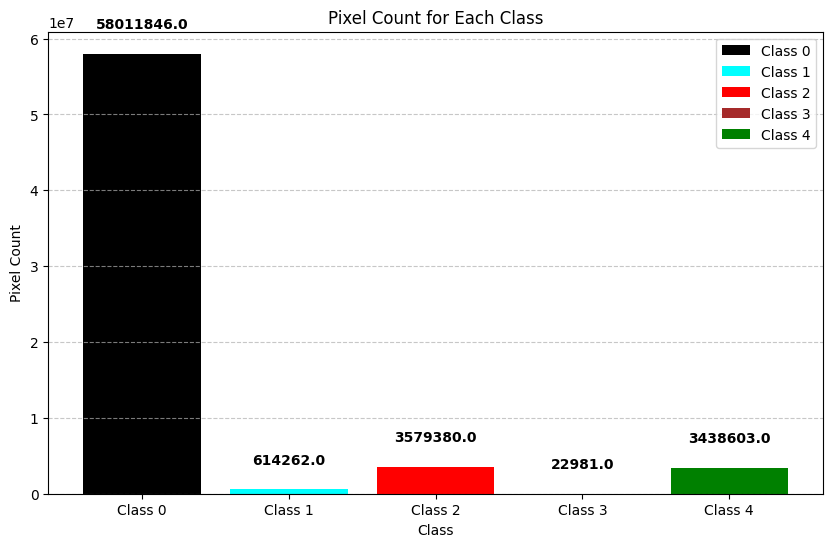

In [ ]:
#pixel counts
num_classes = 5
class_pixel_counts = np.sum(train_masks, axis=(0, 1, 2))
class_labels = [f'Class {i}' for i in range(num_classes)]
colors = ['black', 'cyan', 'red', 'brown', 'green']
plt.figure(figsize=(10, 6))
bars = plt.bar(class_labels, class_pixel_counts, color=colors)
plt.xlabel('Class')
plt.ylabel('Pixel Count')
plt.title('Pixel Count for Each Class')
plt.legend(bars, class_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, count in zip(bars, class_pixel_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05 * max(class_pixel_counts),
             f'{count}', ha='center', va='bottom', color='black', fontweight='bold')

plt.show()


Model architecture Starts here

In [ ]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [ ]:
def channel_attention(x, reduction=8):
         channels = x.shape[-1]

         # Wrap TensorFlow operations in Keras Layers
         avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)(x)
         max_pool = tf.keras.layers.GlobalMaxPooling2D(keepdims=True)(x)


         dense1 = Conv2D(channels // reduction, (1, 1), activation='relu')(avg_pool)
         dense2 = Conv2D(channels // reduction, (1, 1), activation='relu')(max_pool)

         dense1 = Conv2D(channels, (1, 1))(dense1)
         dense2 = Conv2D(channels, (1, 1))(dense2)

         out = tf.keras.layers.Add()([dense1, dense2])
         out = Activation('sigmoid')(out)

         return tf.keras.layers.Multiply()([x, out])

def spatial_attention(x):
        # Wrap TensorFlow operations in Keras Layers
        avg_pool = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
        max_pool = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

        concat = Concatenate(axis=-1)([avg_pool, max_pool])
        out = Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
        return tf.keras.layers.Multiply()([x, out])

def UNet(input_shape, IMG_CLASSES):

    inputs = Input(input_shape)

    c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p2)
    c3 = Dropout(0.1)(c3)
    c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c3)
    p3 = MaxPooling2D((2,2))(c3)

    c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p3)
    c4 = Dropout(0.1)(c4)
    c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c4)
    p4 = MaxPooling2D((2,2))(c4)

    c5 = Conv2D(256, (3,3), activation="relu", padding="same")(p4)
    c5 = Dropout(0.1)(c5)
    c5 = Conv2D(256, (3,3), activation="relu", padding="same")(c5)
    c5 = channel_attention(c5)
    c5 = spatial_attention(c5)

    u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding="same")(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u6)
    c6 = Dropout(0.1)(c6)
    c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c6)

    u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding="same")(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u7)
    c7 = Dropout(0.1)(c7)
    c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c7)

    u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding="same")(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c8)

    u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding="same")(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c9)
    outputs = Conv2D(IMG_CLASSES, (1,1), activation="softmax")(c9)

    model = Model(inputs, outputs)
    return model

In [ ]:
unet_model = UNet(input_shape, IMG_CLASSES)

unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 1,974,616 (7.53 MB)

 Trainable params: 1,974,616 (7.53 MB)

 Non-trainable params: 0 (0.00 B)

Custom boundary Loss function

In [ ]:
def categorical_loss(y_true, y_pred):
    return tf.keras.losses.categorical_crossentropy(y_true, y_pred)

In [ ]:
def boundary_loss(y_true, y_pred):
    # Extract edges from both masks using Sobel
    true_edges = tf.image.sobel_edges(y_true)
    pred_edges = tf.image.sobel_edges(y_pred)

    # Compute difference between true and predicted edges
    edge_diff = tf.abs(true_edges - pred_edges)
    edge_loss = tf.reduce_mean(edge_diff)

    return edge_loss

In [ ]:
def jaccard_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)

    # Sum over H and W, keep class dimension
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2]) - intersection

    iou = (intersection + smooth) / (union + smooth)

    # Average over classes and batch
    return 1 - tf.reduce_mean(iou)

In [ ]:
def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)

    # Sum over H and W, keep class dimension
    TP = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    FP = tf.reduce_sum((1 - y_true) * y_pred, axis=[1, 2])
    FN = tf.reduce_sum(y_true * (1 - y_pred), axis=[1, 2])

    tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)

    # Average over classes and batch
    return 1 - tf.reduce_mean(tversky)


In [ ]:
def combined_loss(y_true, y_pred):
    ce = categorical_loss(y_true, y_pred)
    jl = jaccard_loss(y_true, y_pred)
    tv = tversky_loss(y_true, y_pred)
    bl = boundary_loss(y_true, y_pred)

    return (
        ce
        + 0.3 * jl
        + 0.3 * tv
        + 0.2 * bl
    )

Pre-Training Process

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
unet_model.compile(
    optimizer="adam",
    loss=combined_loss,
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
checkpoint = ModelCheckpoint("best_unet_model.keras",monitor="val_loss",mode="min",save_best_only=True,verbose=1)

Training

In [ ]:
#unet_model.compile()
unet_history = unet_model.fit(train_images, train_masks,
                    epochs=100,
                    batch_size=16,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=[checkpoint])

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.6920 - loss: 1.4926
Epoch 1: val_loss improved from inf to 0.94960, saving model to best_unet_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 77s 690ms/step - accuracy: 0.6943 - loss: 1.4880 - val_accuracy: 0.8967 - val_loss: 0.9496
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8811 - loss: 1.0195
Epoch 2: val_loss improved from 0.94960 to 0.90064, saving model to best_unet_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.8812 - loss: 1.0193 - val_accuracy: 0.8967 - val_loss: 0.9006
Epoch 3/100
56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8816 - loss: 0.9653
Epoch 3: val_loss improved from 0.90064 to 0.88608, saving model to best_unet_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.8816 - loss: 0.9646 - val_accuracy: 0.9100 - val_loss: 0.8861
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8947 - loss: 0.8694
Epoch 4: val_loss improved from 0.

In [ ]:
unet_model.save(modelsave)
unet_model.save_weights(modelweightsave)

Analysis:

Training Accuracy and Loss

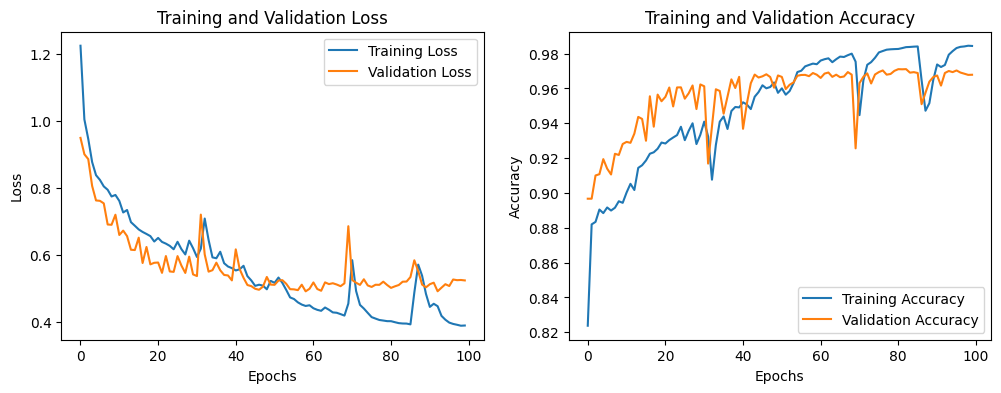

In [ ]:
# Access the training history
unet_loss = unet_history.history['loss']
unet_val_loss = unet_history.history['val_loss']
unet_accuracy = unet_history.history['accuracy']
unet_val_accuracy = unet_history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(unet_loss, label='Training Loss')
plt.plot(unet_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(unet_accuracy, label='Training Accuracy')
plt.plot(unet_val_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

history_df = pd.DataFrame(unet_history.history)
history_df.to_csv(modelhistory, index=False)

Testing:

In [ ]:
prediction_unet = unet_model.predict(test_images)

print(test_masks.shape)
print(prediction_unet.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
(110, 256, 256, 1)
(110, 256, 256, 5)


In [ ]:
# Convert prediction to class labels (no post-processing)
pred_masks = np.argmax(prediction_unet, axis=-1)

# Directly use predicted masks
processed_pred_masks = pred_masks

# Flatten for metrics
unet_true_labels = test_masks.flatten()
unet_predicted_labels = processed_pred_masks.flatten()

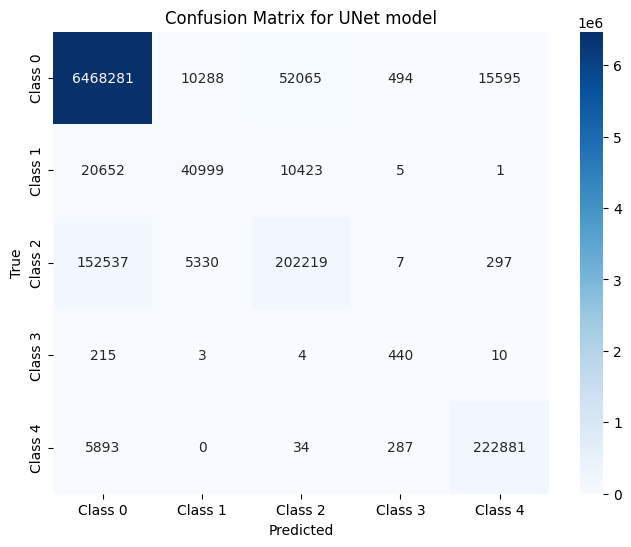

In [ ]:
# Create the confusion matrix
cm = confusion_matrix(unet_true_labels, unet_predicted_labels)

# Save confusion matrix as CSV
pd.DataFrame(cm,
             index=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],
             columns=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
            ).to_csv(confusionmatrixcsv, index=True)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for UNet model')

# Save plot as PNG
plt.savefig(confusionmatrix, bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap

i = 25  # Index of a test image (try a few)
image = test_images[i]
true_mask = test_masks[i]

# Create a custom colormap from the COLOR_MAP list
n_classes = len(COLOR_MAP)
normalized_colors = np.array(COLOR_MAP) / 255.0
cmap = ListedColormap(normalized_colors)

test_image_number = random.randint(0, len(test_images) - 1)

num_images_to_plot = 110
for i in range(num_images_to_plot):
    plt.figure(figsize=(12, 6))  # Adjust the figure size as needed

    # Test Image
    plt.subplot(1, 3, 1)  # Subplot for the image
    test_image = test_images[i]
    plt.imshow(test_image)  # Display the image
    plt.title("Image")

    # Test Mask
    plt.subplot(1, 3, 2)  # Subplot for the test mask
    test_mask = test_masks[i]
    plt.imshow(test_mask.squeeze(), cmap=cmap, vmin=0, vmax=len(COLOR_MAP) - 1, interpolation='none')
    plt.colorbar(ticks=range(len(COLOR_MAP)))
    plt.title("Test Mask")

    # Predicted Mask
    plt.subplot(1, 3, 3)  # Subplot for the predicted mask
    prediction_unet = unet_model.predict(np.expand_dims(test_image, axis=0))
    predicted_mask_unet = np.argmax(prediction_unet, axis=3)[0, :, :]
    plt.imshow(predicted_mask_unet.squeeze(), cmap=cmap, vmin=0, vmax=len(COLOR_MAP) - 1, interpolation='none')
    plt.colorbar(ticks=range(len(COLOR_MAP)))
    plt.title("Predicted Mask")

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

Metrics

In [ ]:
# Dice coefficient
def dice_score(y_true, y_pred, cls):
    y_true_c = (y_true == cls).astype(np.int32)
    y_pred_c = (y_pred == cls).astype(np.int32)
    intersection = np.sum(y_true_c * y_pred_c)
    return (2.0 * intersection) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)

# Per-class accuracy
def per_class_accuracy(y_true, y_pred, cls):
    y_true_c = (y_true == cls).astype(np.int32)
    y_pred_c = (y_pred == cls).astype(np.int32)
    TP = np.sum((y_true_c == 1) & (y_pred_c == 1))
    TN = np.sum((y_true_c == 0) & (y_pred_c == 0))
    FP = np.sum((y_true_c == 0) & (y_pred_c == 1))
    FN = np.sum((y_true_c == 1) & (y_pred_c == 0))
    return (TP + TN) / (TP + TN + FP + FN + 1e-7)

# Initialize table
results = []

classes = np.unique(unet_true_labels)

# Per-class metrics
for cls in classes:
    cls_precision = precision_score(unet_true_labels, unet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_recall = recall_score(unet_true_labels, unet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_f1 = f1_score(unet_true_labels, unet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_iou = jaccard_score(unet_true_labels, unet_predicted_labels, average=None, labels=[cls], zero_division=0)[0]
    cls_dice = dice_score(unet_true_labels, unet_predicted_labels, cls)
    cls_accuracy = per_class_accuracy(unet_true_labels, unet_predicted_labels, cls)

    results.append({
        "Class": cls,
        "Precision": cls_precision,
        "Recall": cls_recall,
        "F1": cls_f1,
        "IoU": cls_iou,
        "Dice": cls_dice,
        "Accuracy": cls_accuracy
    })

# Macro average (equal weight for all classes)
macro_precision = precision_score(unet_true_labels, unet_predicted_labels, average="macro", zero_division=0)
macro_recall = recall_score(unet_true_labels, unet_predicted_labels, average="macro", zero_division=0)
macro_f1 = f1_score(unet_true_labels, unet_predicted_labels, average="macro", zero_division=0)
macro_iou = jaccard_score(unet_true_labels, unet_predicted_labels, average="macro", zero_division=0)
macro_dice = np.mean([dice_score(unet_true_labels, unet_predicted_labels, cls) for cls in classes])
macro_accuracy = np.mean([per_class_accuracy(unet_true_labels, unet_predicted_labels, cls) for cls in classes])

results.append({
    "Class": "Macro Avg",
    "Precision": macro_precision,
    "Recall": macro_recall,
    "F1": macro_f1,
    "IoU": macro_iou,
    "Dice": macro_dice,
    "Accuracy": macro_accuracy
})

# Weighted / overall metrics
weighted_precision = precision_score(unet_true_labels, unet_predicted_labels, average="weighted", zero_division=0)
weighted_recall = recall_score(unet_true_labels, unet_predicted_labels, average="weighted", zero_division=0)
weighted_f1 = f1_score(unet_true_labels, unet_predicted_labels, average="weighted", zero_division=0)
weighted_iou = jaccard_score(unet_true_labels, unet_predicted_labels, average="weighted", zero_division=0)
weighted_dice = np.sum([dice_score(unet_true_labels, unet_predicted_labels, cls) *
                        np.sum(unet_true_labels == cls) for cls in classes]) / len(unet_true_labels)
weighted_accuracy = accuracy_score(unet_true_labels, unet_predicted_labels)

results.append({
    "Class": "Weighted / Overall",
    "Precision": weighted_precision,
    "Recall": weighted_recall,
    "F1": weighted_f1,
    "IoU": weighted_iou,
    "Dice": weighted_dice,
    "Accuracy": weighted_accuracy
})

# Create DataFrame with fixed column order
df = pd.DataFrame(results)
cols = ["Class", "Precision", "Recall", "F1", "IoU", "Dice", "Accuracy"]
df = df[cols]

# Save to CSV
df.to_csv(modelmetricscsv, index=False)

# Print neatly
print("Saved metrics to atun_metrics.csv")
print(df.to_string(index=False, float_format="%.6f"))


Saved metrics to atun_metrics.csv
             Class  Precision   Recall       F1      IoU     Dice  Accuracy
                 0   0.973028 0.988018 0.980466 0.961680 0.980466  0.964247
                 1   0.724108 0.568799 0.637125 0.467486 0.637125  0.993522
                 2   0.763826 0.561112 0.646961 0.478154 0.646961  0.969386
                 3   0.356853 0.654762 0.461942 0.300341 0.461942  0.999858
                 4   0.933400 0.972876 0.952729 0.909726 0.952729  0.996932
         Macro Avg   0.750243 0.749113 0.735845 0.623478 0.735845  0.984789
Weighted / Overall   0.958764 0.961972 0.959431 0.930854 0.959431  0.961972


Regression Matrix

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# --- Flatten masks (already done above) ---
y_true = unet_true_labels
y_pred = unet_predicted_labels

# --- Regression Metrics ---
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# MAPE (Mean Absolute Percentage Error) - avoid division by zero
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-7))) * 100

# MSLE (Mean Squared Logarithmic Error) - works only if values >= 0
msle = mean_squared_error(np.log1p(y_true), np.log1p(y_pred))

# --- Save all metrics to CSV ---
regression_results = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2,
    "MAPE": mape,
    "MSLE": msle
}

df_regression = pd.DataFrame([regression_results])
df_regression.to_csv(regmetrics, index=False)

print("Regression metrics saved to lapunet_regression_metrics.csv")
print(df_regression.to_string(index=False, float_format="%.6f"))